In [1]:
import cv2
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"

IMAGE_DIR = DATA_DIR / "eye_image"

PROCESSED_DIR = DATA_DIR / "processed_images"

PROCESSED_DIR.mkdir(exist_ok=True)

print(PROCESSED_DIR)

..\data\processed_images


In [4]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

image_paths = [
    p for p in IMAGE_DIR.rglob("*")
    if p.suffix.lower() in IMAGE_EXTENSIONS
]

print(f"Total Images : {len(image_paths)}")

Total Images : 862


In [5]:
def read_image(image_path: Path):
    """
    Read image using OpenCV.
    Returns None if unreadable.
    """

    img = cv2.imread(str(image_path))

    if img is None:
        return None

    return img

In [6]:
sample = image_paths[0]

img = read_image(sample)

print(img.shape)

(3984, 2988, 3)


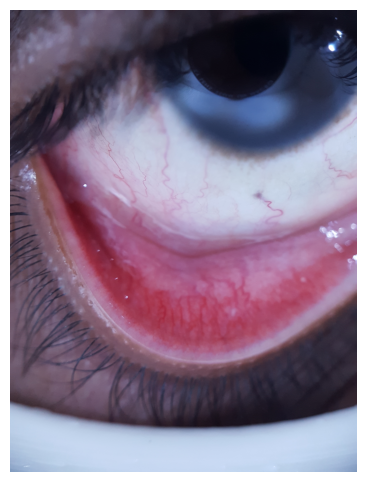

In [7]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))

plt.imshow(rgb)

plt.axis("off")

plt.show()

In [8]:
PROCESSED_DIR = DATA_DIR / "processed_images"

PROCESSED_DIR.mkdir(exist_ok=True)

print(PROCESSED_DIR)

..\data\processed_images


In [9]:
def apply_clahe(image):
    """
    Apply CLAHE on the L-channel in LAB color space.
    """

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    enhanced = cv2.merge((l, a, b))

    enhanced = cv2.cvtColor(
        enhanced,
        cv2.COLOR_LAB2BGR
    )

    return enhanced

In [10]:
IMAGE_SIZE = 224

def resize_image(image):

    return cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA
    )

In [11]:
def normalize_image(image):

    image = image.astype(np.float32)

    image /= 255.0

    return image

In [12]:
def preprocess_image(image_path):

    image = cv2.imread(str(image_path))

    if image is None:
        return None

    image = apply_clahe(image)

    image = resize_image(image)

    image = normalize_image(image)

    return image

In [13]:
processed = preprocess_image(image_paths[0])

print(processed.shape)

print(processed.min())

print(processed.max())

(224, 224, 3)
0.0
1.0


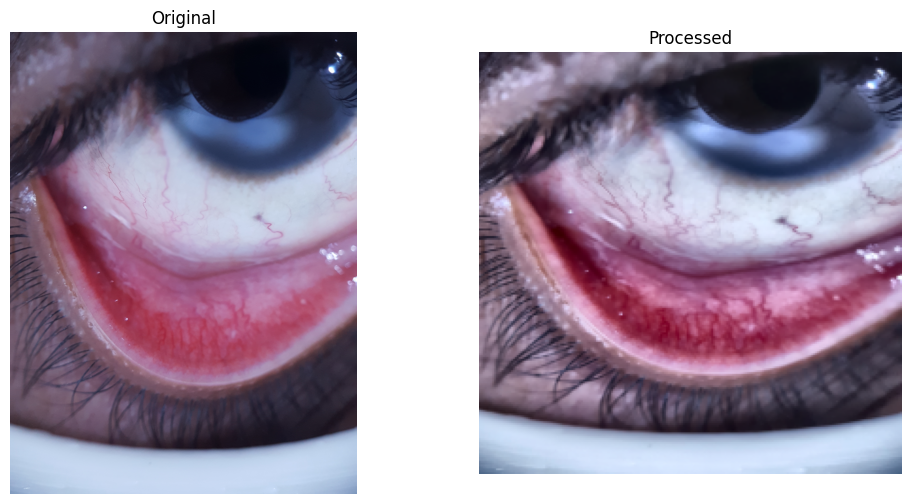

In [14]:
original = cv2.imread(str(image_paths[0]))

processed = preprocess_image(image_paths[0])

original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

processed_display = (processed * 255).astype(np.uint8)

processed_display = cv2.cvtColor(
    processed_display,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)

plt.imshow(original)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(processed_display)

plt.title("Processed")

plt.axis("off")

plt.show()

In [15]:
from tqdm import tqdm

saved = 0

for img_path in tqdm(image_paths):

    processed = preprocess_image(img_path)

    if processed is None:
        continue

    relative = img_path.relative_to(IMAGE_DIR)

    output_path = PROCESSED_DIR / relative

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    output = (processed * 255).astype(np.uint8)

    cv2.imwrite(
        str(output_path),
        output
    )

    saved += 1

print(f"Saved Images : {saved}")

100%|██████████| 862/862 [02:48<00:00,  5.11it/s]

Saved Images : 862
